
## Introduction & Objectives
The primary goal of this notebook is to perform exploratory data analysis (EDA) on a stroke dataset to identify key cardiovascular risk factors. The main focus is to provide meaningful and clear data driven insights regarding cardiovascular risk factors through rigorous data profiling, feature engineering, and mathematical validation. By combining visual analytics with statistical strictness, this notebook aims to provide a reliable risk profile identifying the key drivers of stroke events.

### 1. Import all the neccessary libraries for the project

In [2]:
import warnings
from IPython.core.pylabtools import figsize
from unicodedata import category

warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder




In [3]:
sns.set_theme(style="whitegrid", palette="muted")
sns.color_palette("hls", 8)

def load_the_data(filepath: str) -> pd.DataFrame:
    df = pd.read_csv(filepath)
    return df

df = load_the_data('healthcare-dataset-stroke-data.xls')

| Target Variables

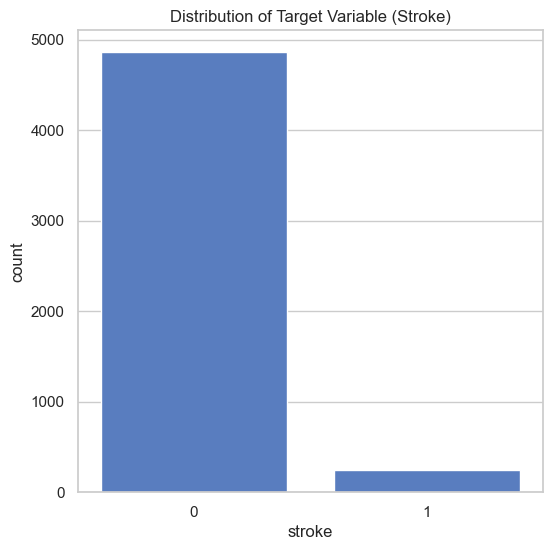

In [4]:
def target_variables(dataframe) -> None:

    plt.figure(figsize=(6, 6))
    sns.countplot(x=dataframe['stroke'])
    plt.title("Distribution of Target Variable (Stroke)")
    plt.show()

target_variables(df)

In [5]:
print(df.shape)
print(df.describe())
print(df.info())

(5110, 12)
                 id          age  hypertension  heart_disease  \
count   5110.000000  5110.000000   5110.000000    5110.000000   
mean   36517.829354    43.226614      0.097456       0.054012   
std    21161.721625    22.612647      0.296607       0.226063   
min       67.000000     0.080000      0.000000       0.000000   
25%    17741.250000    25.000000      0.000000       0.000000   
50%    36932.000000    45.000000      0.000000       0.000000   
75%    54682.000000    61.000000      0.000000       0.000000   
max    72940.000000    82.000000      1.000000       1.000000   

       avg_glucose_level          bmi       stroke  
count        5110.000000  4909.000000  5110.000000  
mean          106.147677    28.893237     0.048728  
std            45.283560     7.854067     0.215320  
min            55.120000    10.300000     0.000000  
25%            77.245000    23.500000     0.000000  
50%            91.885000    28.100000     0.000000  
75%           114.090000    33.1

In [6]:
print(df.isna().sum())

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


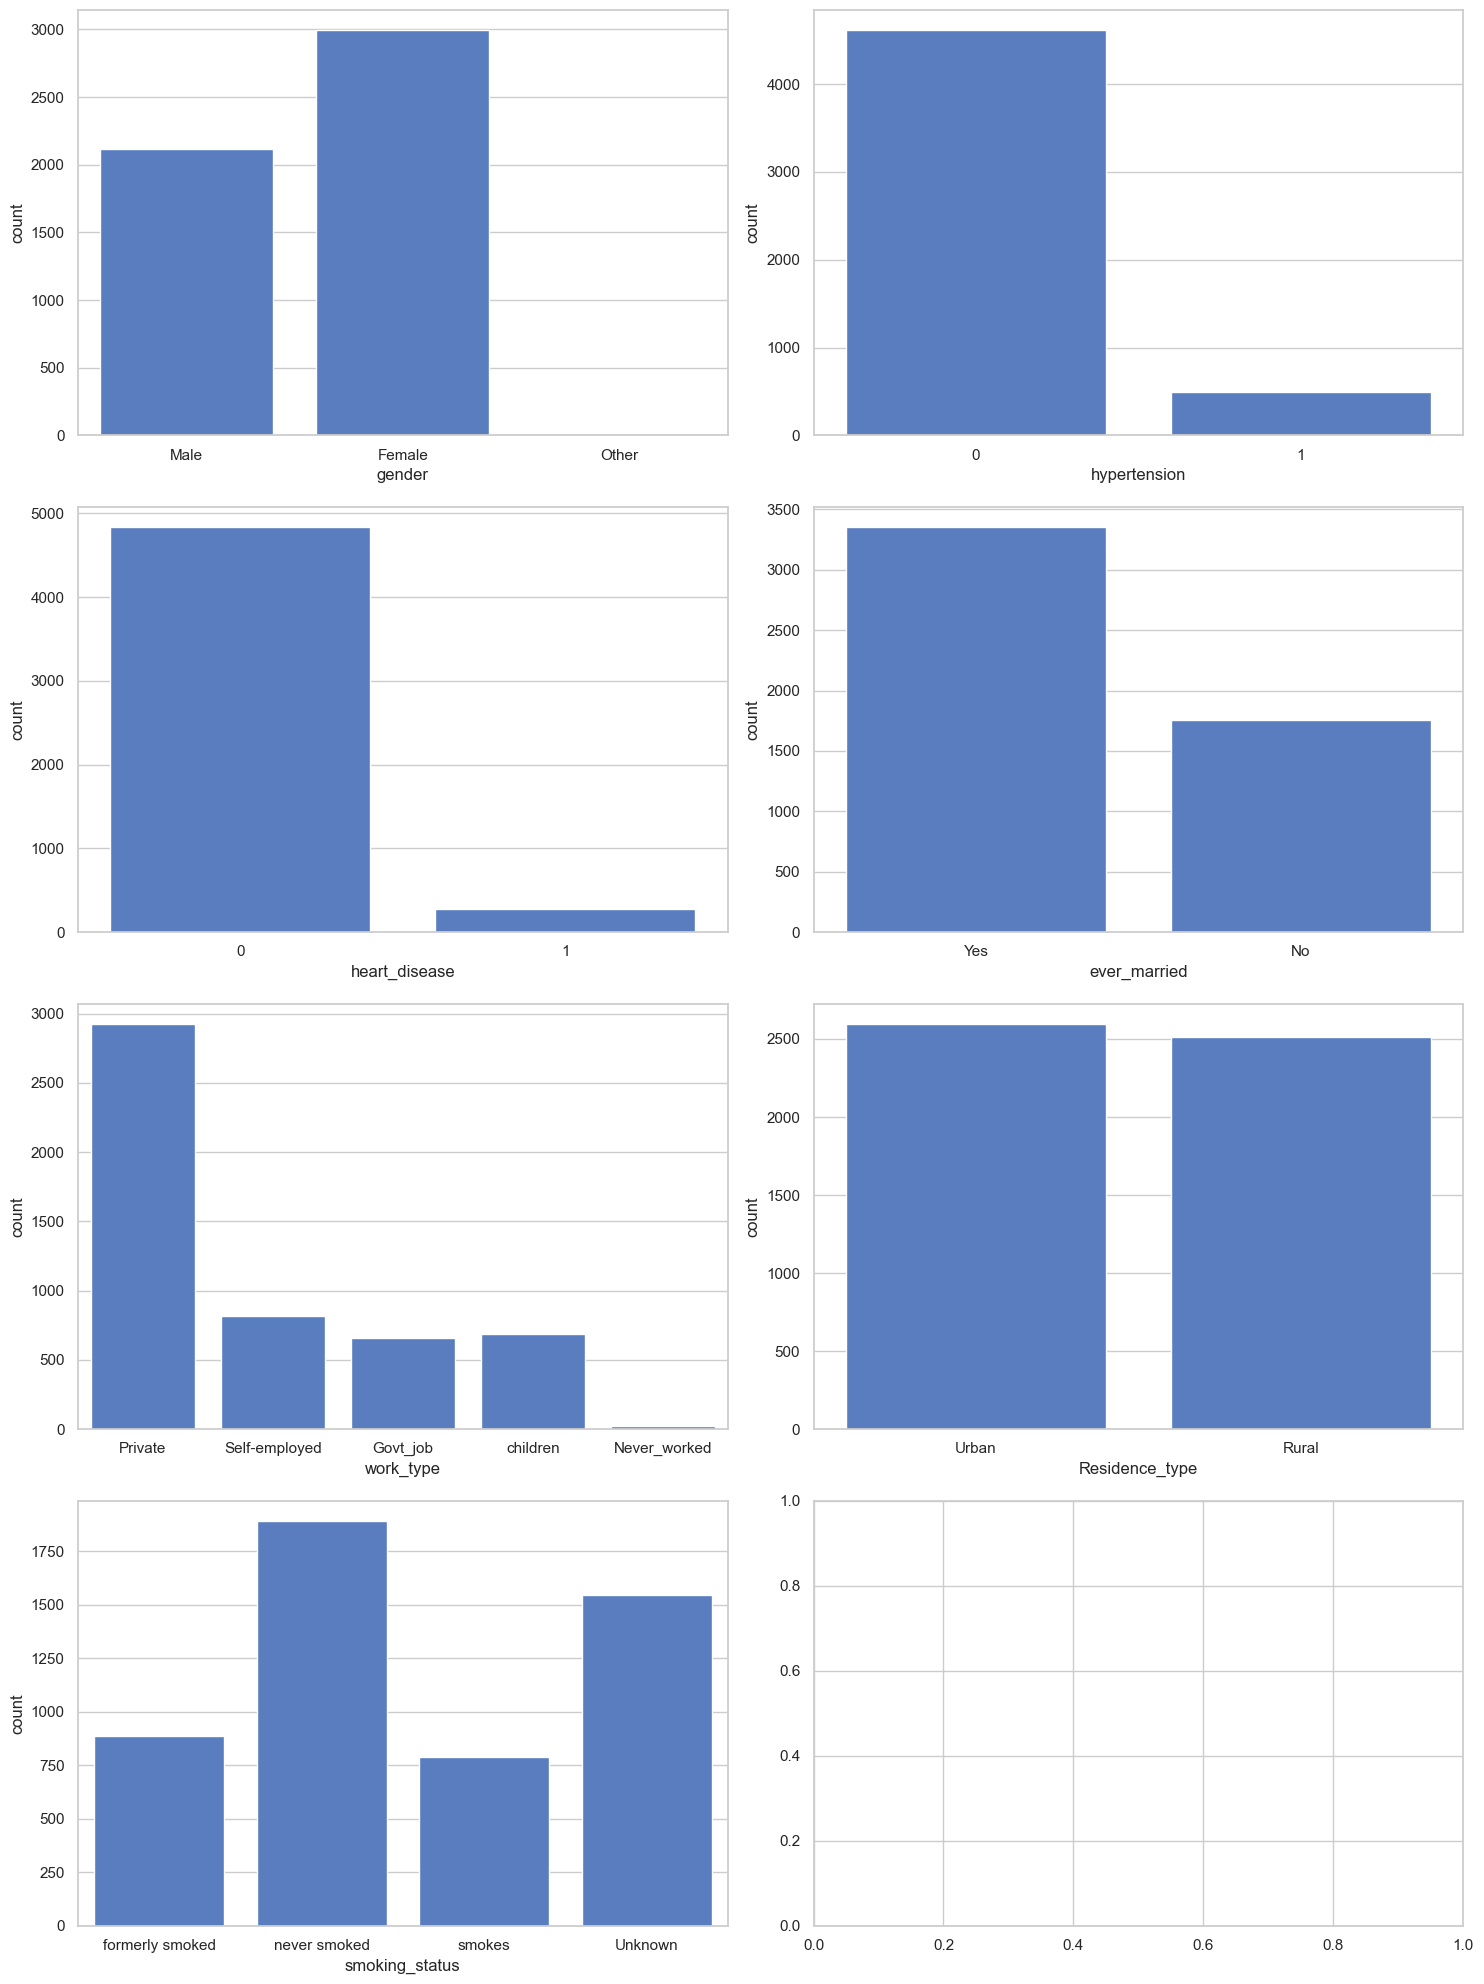

In [7]:
def category_vairables(dataframe) -> None:
    categorical_variables = ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


    fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15,20))


    for var, subplot in zip(categorical_variables, axes.flatten()):
        sns.countplot(x=var, data=dataframe, ax=subplot)
    '''    for label in subplot.get_xticklabels():
            label.set_rotation(45)'''

    plt.tight_layout()
    plt.show()

category_vairables(df)

***The interpretations of the results:***

The key observations of the categorical variables:
gender: There are more female than male patients, and the number of patients who identity themselves as others are quite minute
hypertension: The major part of the pationts do not have hypertension.
heart_disease: The majority of patients do not have heart disease.
ever_married: A high percentage of patients report ever-married status
work_type: The private working employees comprise the largest share of the patient base. Moreover, the self-employed individuals and children also take a considerable part. Meanwhile, public sector workers and those who have never worked account for the lowest percentages.

III | Continous Vairables

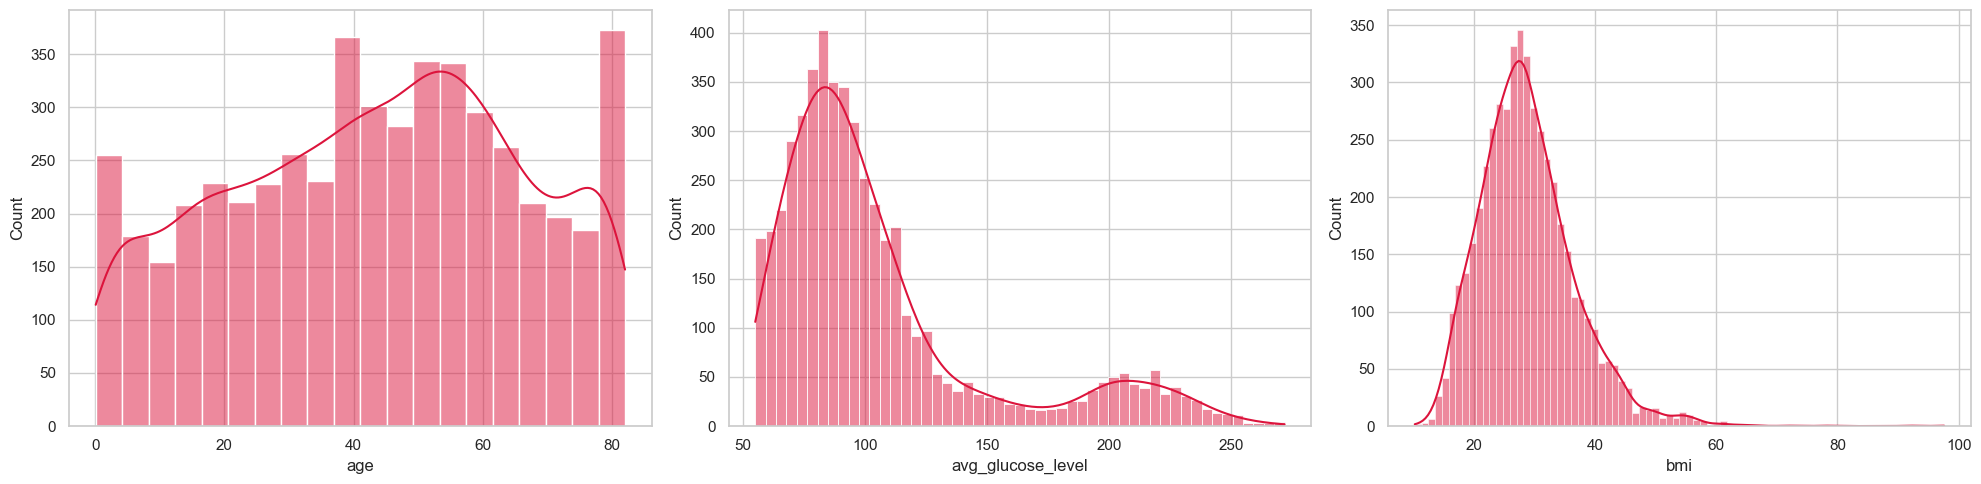

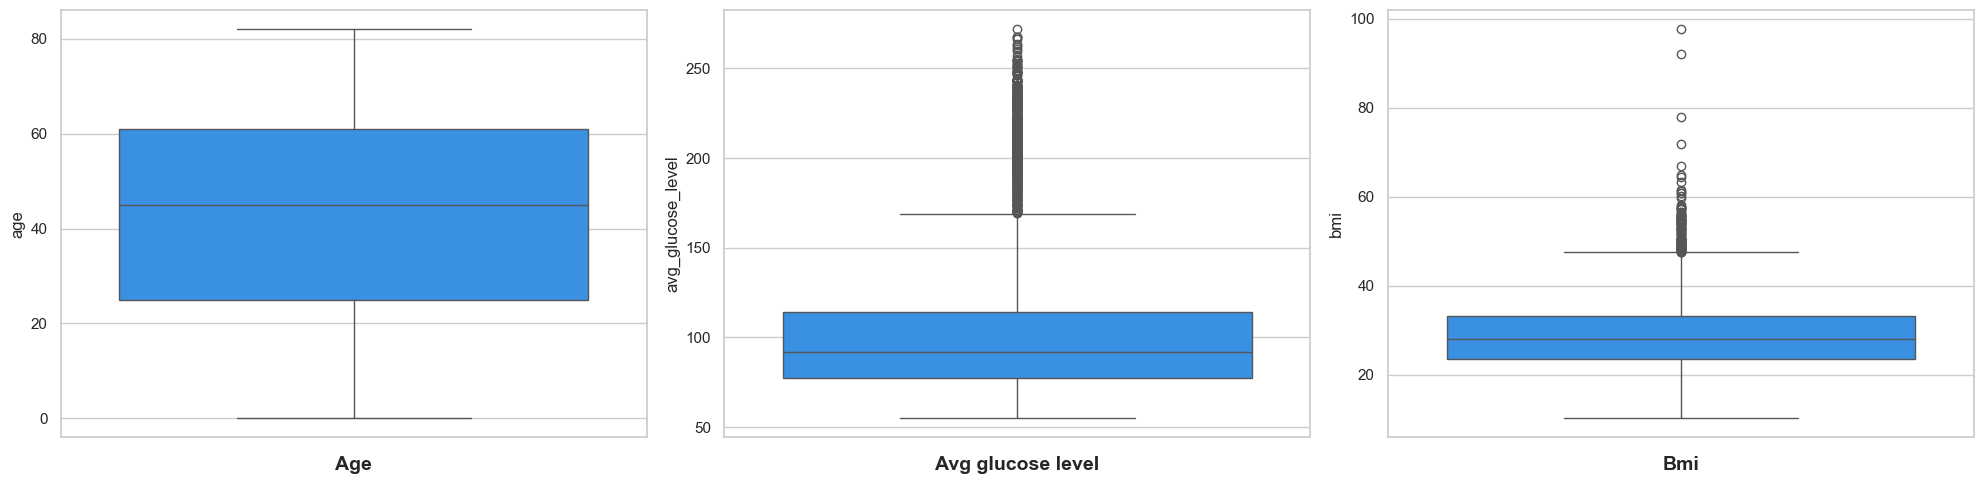

In [8]:
def continuous_variables_histogram(dataframe) -> None:
    continuous_variables = ["age", "avg_glucose_level", "bmi"]
    fig, axs = plt.subplots(1, 3, figsize=(20, 5))

    for var, subplot in zip(continuous_variables, axs.flatten()):
        sns.histplot(dataframe[var], kde=True, ax=subplot, color='crimson')

    plt.tight_layout()
    plt.show()

def continuous_variables_boxplot(dataframe) -> None:
    continuous_variables = ["age", "avg_glucose_level", "bmi"]
    fig, axs = plt.subplots(1, 3, figsize=(20,5))

    for var, subplot in zip(continuous_variables, axs.flatten()):
        sns.boxplot(y=dataframe[var], ax=subplot, color='dodgerblue')
        subplot.set_xlabel(var.replace("_", " "). capitalize(), fontsize=14, fontweight='bold')
        subplot.set_title("")

    plt.tight_layout()
    plt.show()

continuous_variables_histogram(df)
continuous_variables_boxplot(df)

age: the average age of the patients is above 40, and the majority of the patients are between 40-80 years
avg_glucose_level: The major part of the patients have an average glucose level between 50-125. But as we can see on the                  boxplot, there are also many patients with much higer glucose level.
bmi: The majority of the patients have a bmi int the range of 20-40, which is considered normal to overweight, but there are some extremely high outliers as well.

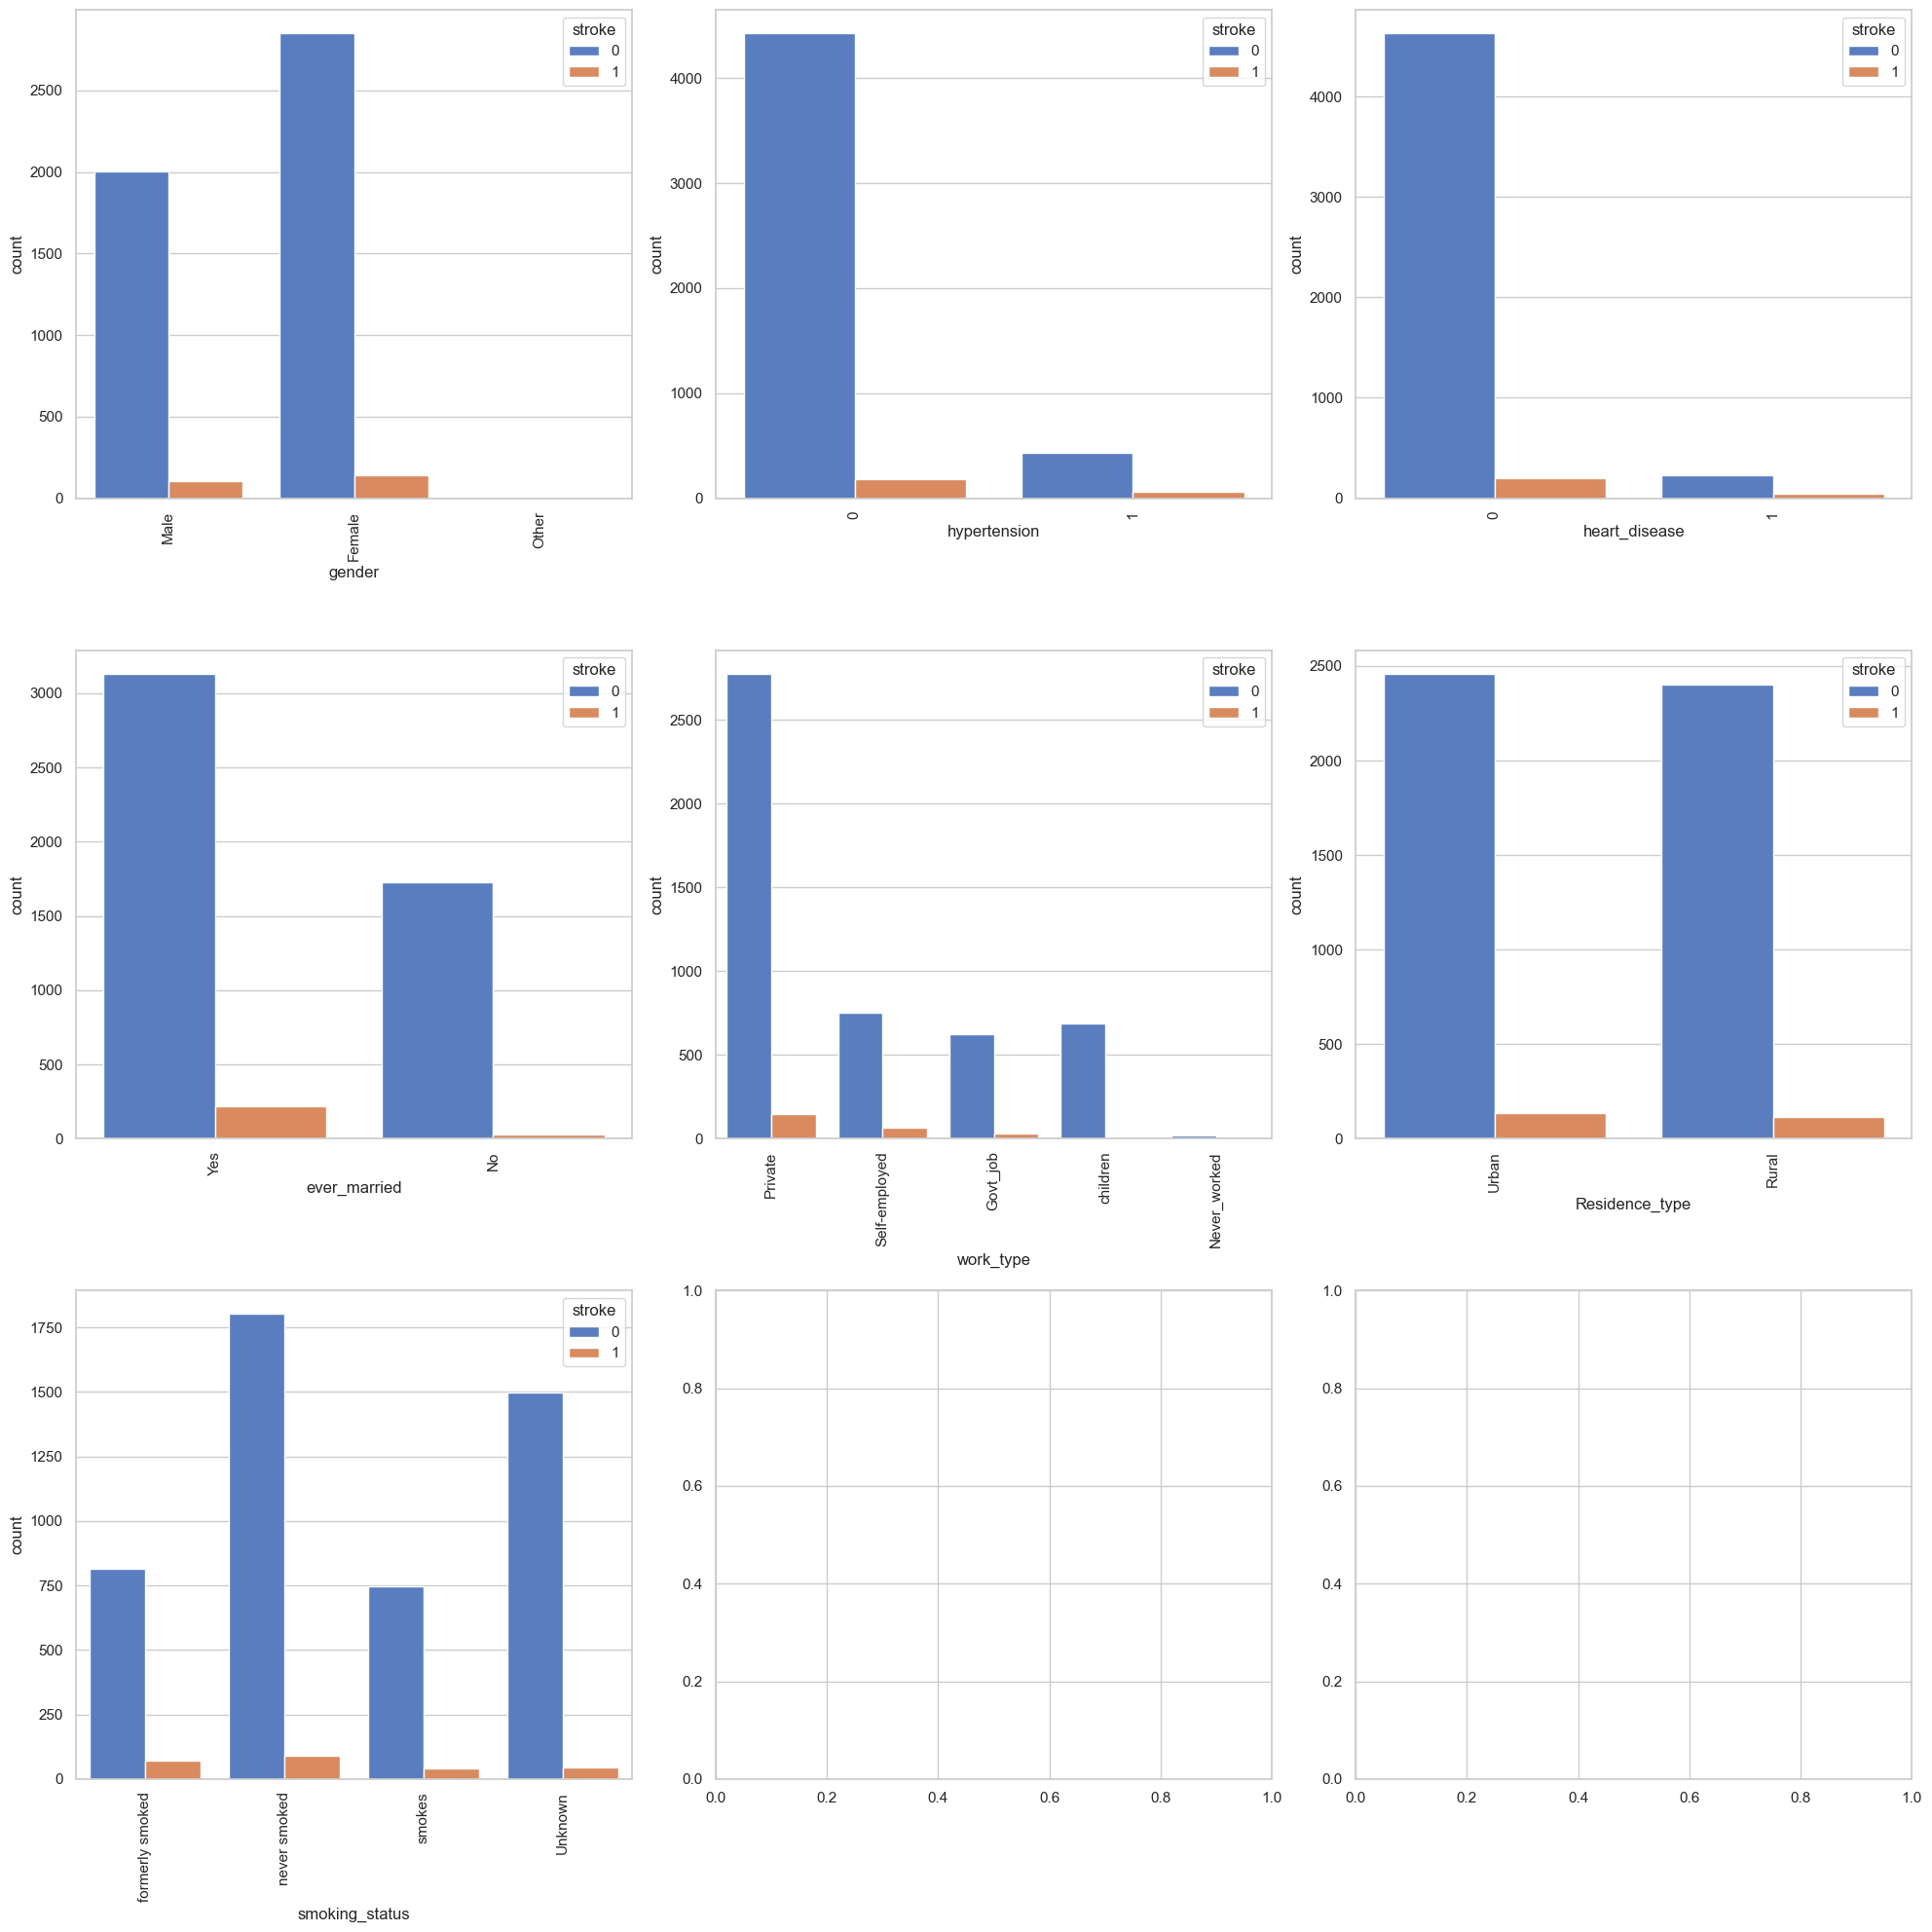

In [9]:
def bivariate_analysis_categorical(dataframe) -> None:
    categorical_variables = ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

    # Javított sor: subplot -> subplots
    fig, axs = plt.subplots(3, 3, figsize=(20,20))

    for var, subplot in zip(categorical_variables, axs.flatten()):
        sns.countplot(x=dataframe[var], hue=dataframe["stroke"], ax=subplot)
        for label in subplot.get_xticklabels():
            label.set_rotation(90)

    plt.tight_layout()
    plt.show()

bivariate_analysis_categorical(df)


gender: Both males and females have a similar proportion of stoke cases, with a males having slightly more.
hypertension: Patients with hypertension have a higher proportion of stroke cases than those without hypertension.
heart_disease: Patients with head disease also have a higher proportion of stroke cases than those without heart disease.
ever_married: Those who have been married have a higher proportion of stroke cases than those who have not.
work_type: Patients who are self-employed or work in private jobs have a higher proportion of stroke cases compared to
           other work types
Residence_type: The proportion of stroke cases is almost equal for both urban and rural residents.
smoking_status: The proportion of stroke cases is higher for patients who formerly smoked or currently smoke compared to               those who never smoked. The stroke proportion for the 'Unknown' category is lower.

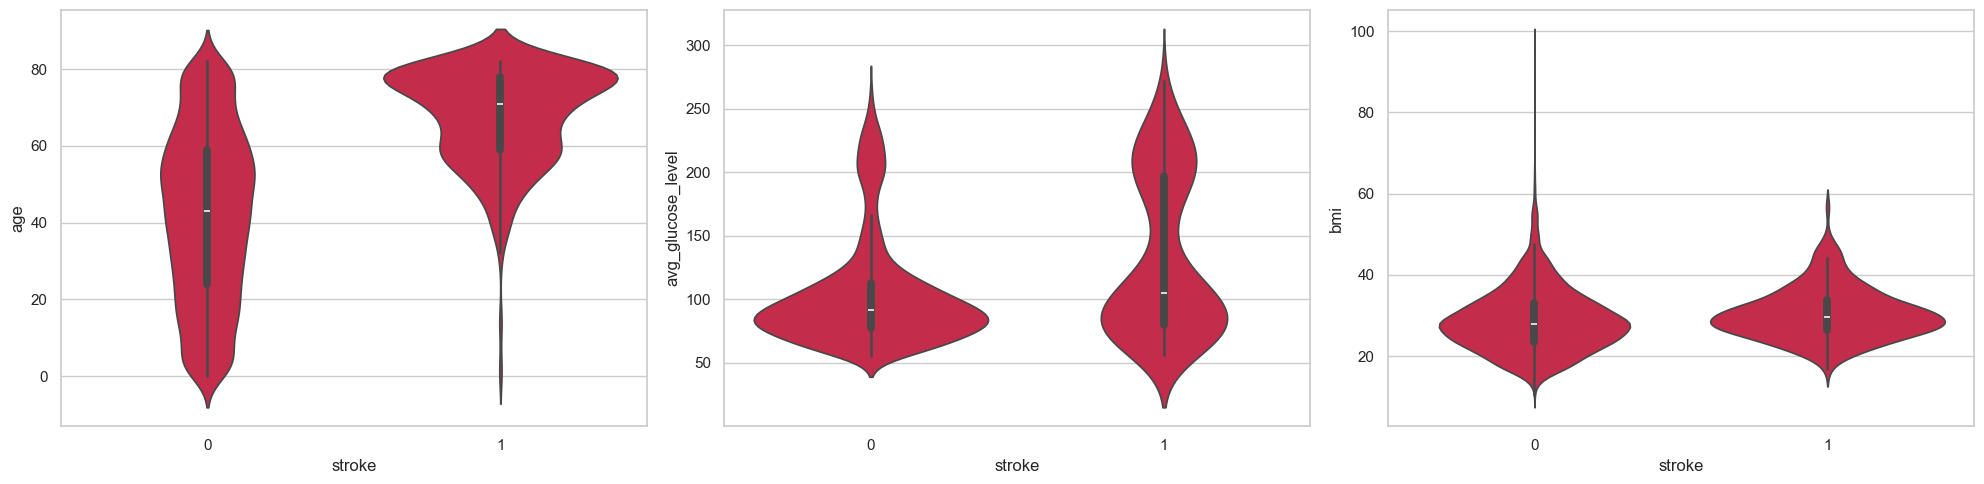

In [10]:
def bivariate_analysis_continuous(dataframe) -> None:
    continuous_variables = ["age", "avg_glucose_level", "bmi"]
    fig, axs = plt.subplots(1,3,figsize=(20,5))
    for var, subplot in zip(continuous_variables, axs.flatten()):
        sns.violinplot(x=dataframe["stroke"], y=dataframe[var], ax=subplot, color="crimson")

    plt.tight_layout()
    plt.show()

bivariate_analysis_continuous(df)

age: Considering the older patients, in their cases it is more common having a stroke than the younger patients.
avg_glucose_level: Those patients who had storke, they have a higher average glucose level than non stroke patients.
                   There is a wider distribution of glucose levels among stroke patients.
bmi: the BMI distribution for stroke and non-stroke patients are quite similar, suggesting that BMI might not be a strong predictor for stroke.

Multivariate Analysis

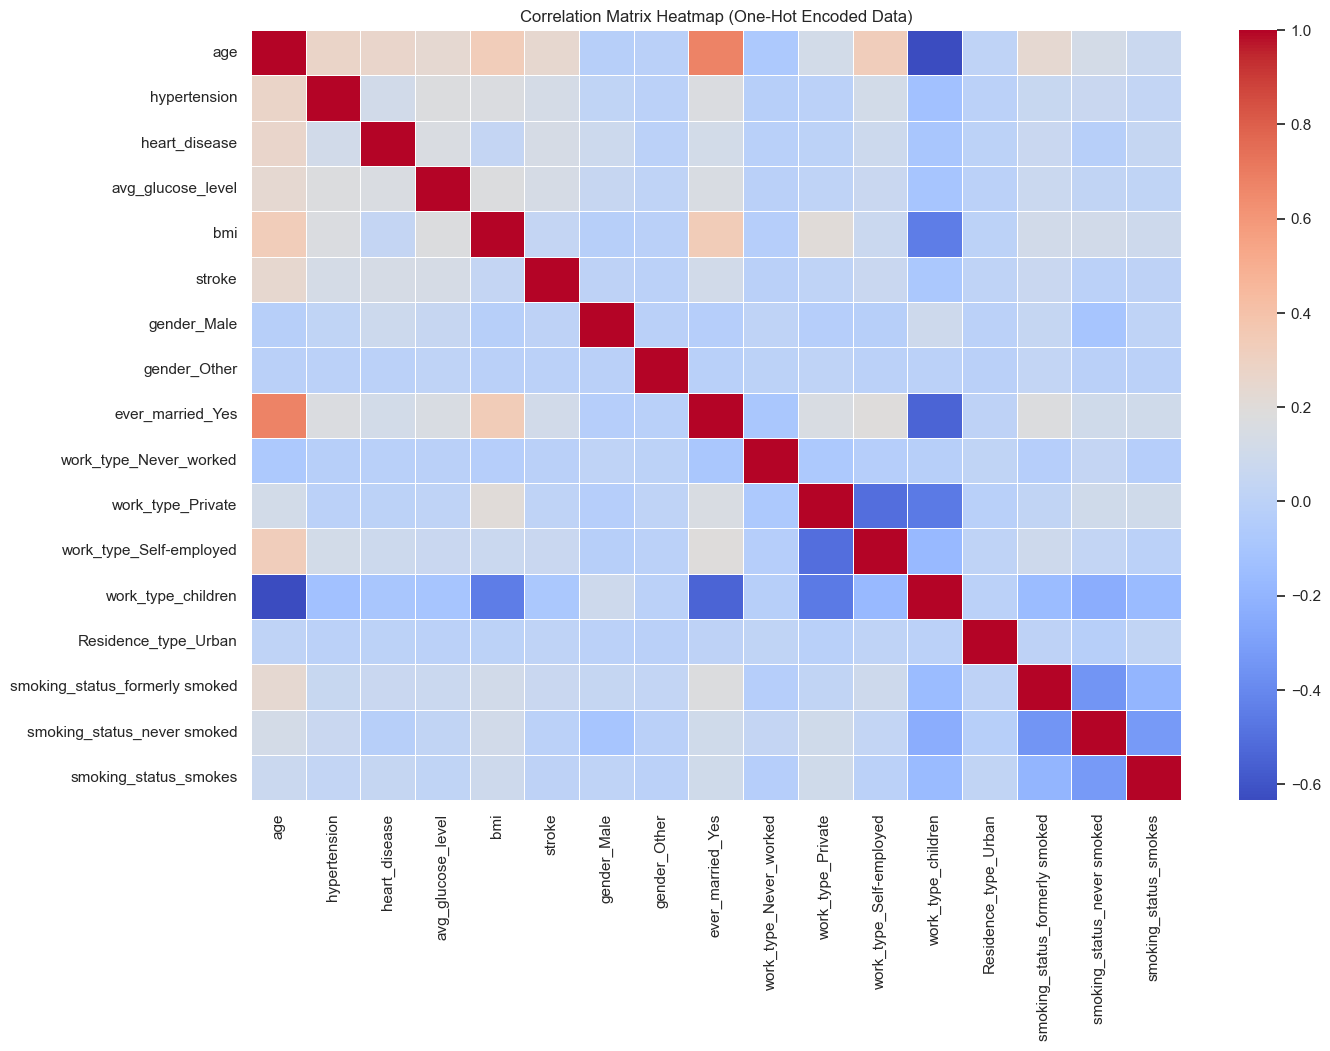

In [11]:
def correlation_matrix(filepath: str):
    data_original = load_the_data(filepath)

    # Javítás: inplace=True hozzáadása az id oszlop végleges törléséhez
    data_original.drop("id", axis=1, inplace=True)

    categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

    # Javítás: 'spare' helyett 'sparse_output' (újabb scikit-learn verziókhoz)
    one_hot_encoder = OneHotEncoder(drop='first', sparse_output=False)

    encoded_array = one_hot_encoder.fit_transform(data_original[categorical_cols])
    one_hot_encoded_df = pd.DataFrame(encoded_array, columns=one_hot_encoder.get_feature_names_out(categorical_cols))

    data_original.drop(categorical_cols, axis=1, inplace=True)
    data_one_hot_encoded = pd.concat([data_original, one_hot_encoded_df], axis=1)

    correlation_matrix_one_hot = data_one_hot_encoded.corr()
    return correlation_matrix_one_hot

def overall_correlation(filepath: str):
    correlation_matrix_one_hot = correlation_matrix(filepath)
    plt.figure(figsize=(15, 10))
    sns.heatmap(correlation_matrix_one_hot, annot=False, cmap='coolwarm', linewidths=0.5)
    plt.title("Correlation Matrix Heatmap (One-Hot Encoded Data)")
    plt.show()

overall_correlation("healthcare-dataset-stroke-data.xls")

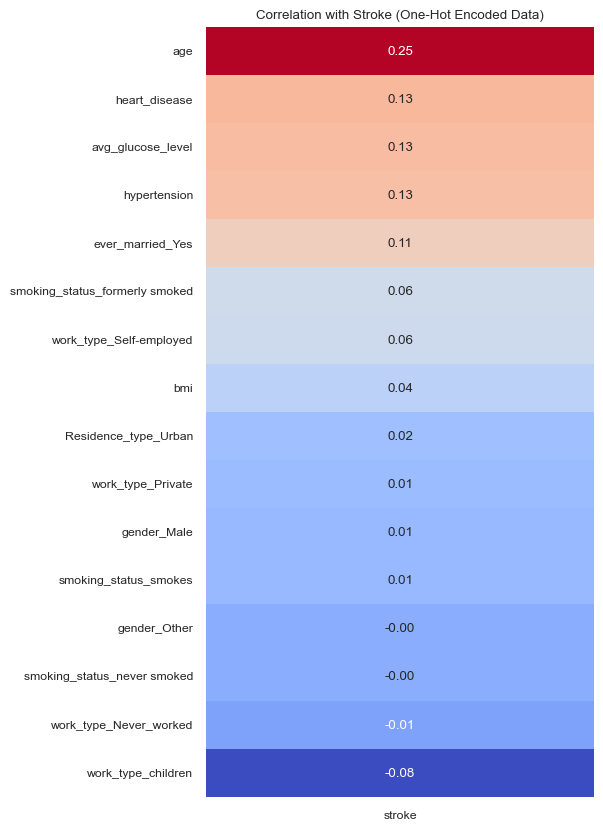

In [12]:
def target_correlation(filepath: str) -> None:
    correlation_matrix_one_hot  = correlation_matrix(filepath)
    target_corr_one_hot  = correlation_matrix_one_hot["stroke"].drop("stroke")
    target_corr_sorted_one_hot = target_corr_one_hot.sort_values(ascending=False)

    plt.figure(figsize=(5,10))
    sns.set(font_scale=0.8)
    sns.set_style("white")
    sns.set_palette("PuBuGn_d")
    sns.heatmap(target_corr_sorted_one_hot.to_frame(), cmap="coolwarm", annot=True, fmt=".2f", cbar=False)
    plt.title("Correlation with Stroke (One-Hot Encoded Data)")
    plt.show()

target_correlation("healthcare-dataset-stroke-data.xls")


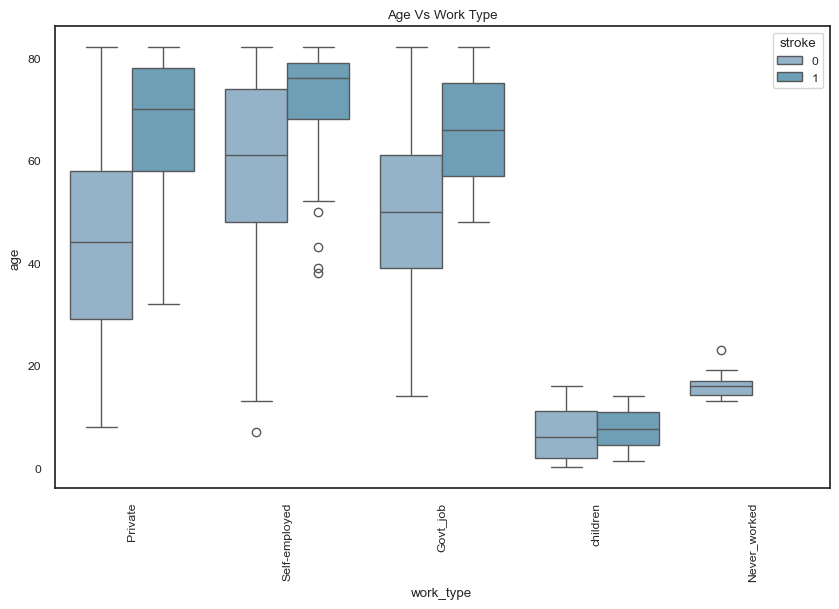

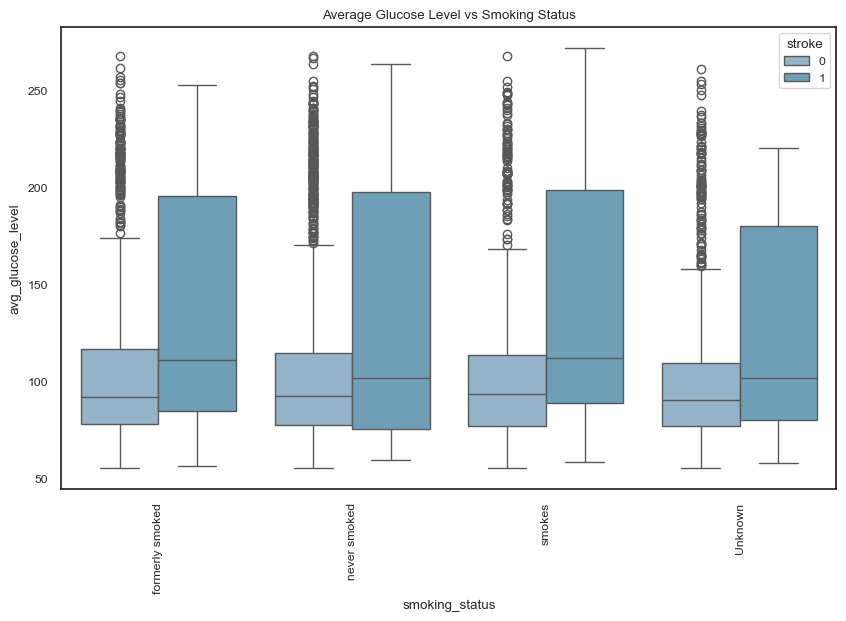

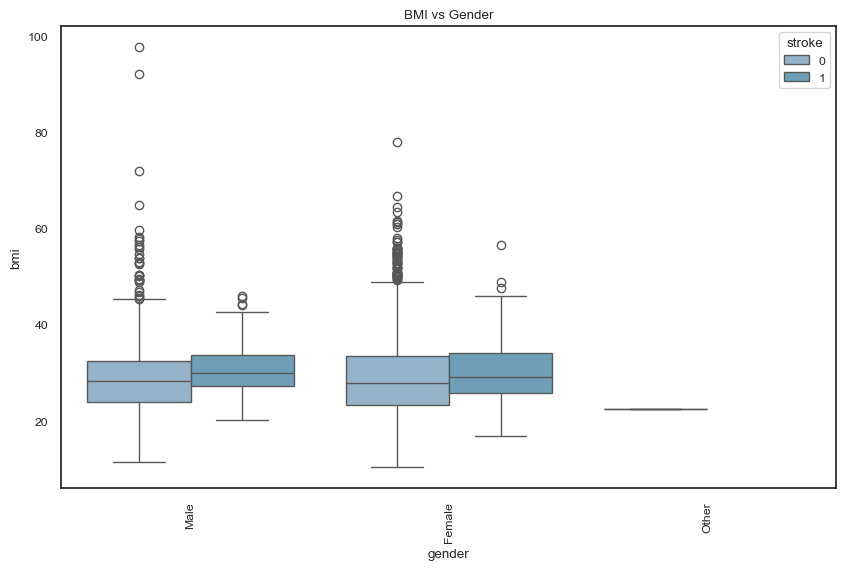

In [14]:
def age_worktype_boxplot(datarame) -> None:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=datarame['work_type'], y=datarame['age'], hue=datarame['stroke'])
    plt.title("Age Vs Work Type")
    plt.xticks(rotation=90)
    plt.show()


def avg_glucose_level_vs_smoking_boxplot(datarame) -> None:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=datarame['smoking_status'], y=datarame['avg_glucose_level'], hue=datarame['stroke'])
    plt.title("Average Glucose Level vs Smoking Status")
    plt.xticks(rotation=90)
    plt.show()


def bmi_vs_gender_boxplot(datarame) -> None:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=datarame['gender'], y=datarame['bmi'], hue=datarame['stroke'])
    plt.title("BMI vs Gender")
    plt.xticks(rotation=90)
    plt.show()


age_worktype_boxplot(df)
avg_glucose_level_vs_smoking_boxplot(df)
bmi_vs_gender_boxplot(df)



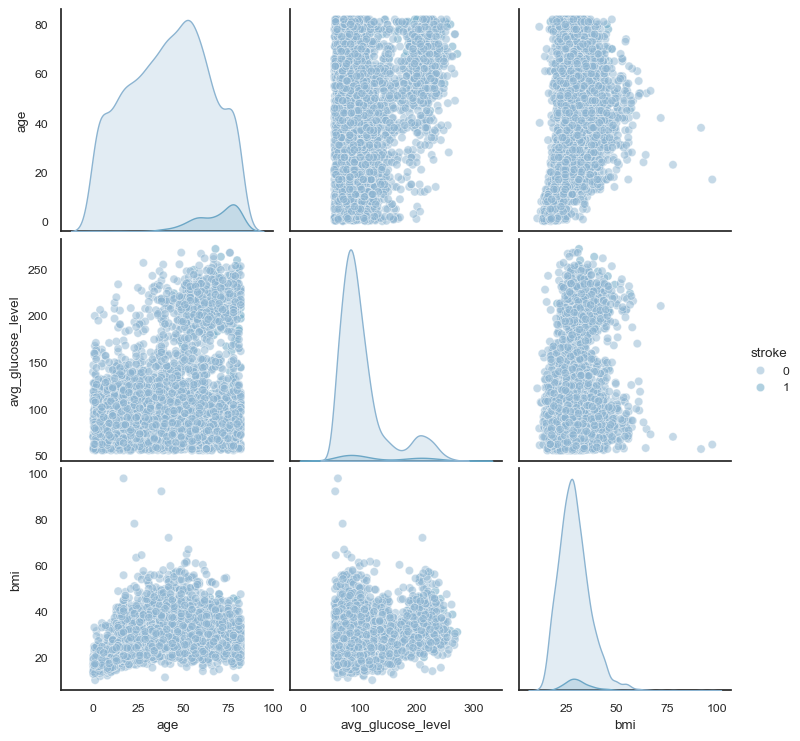

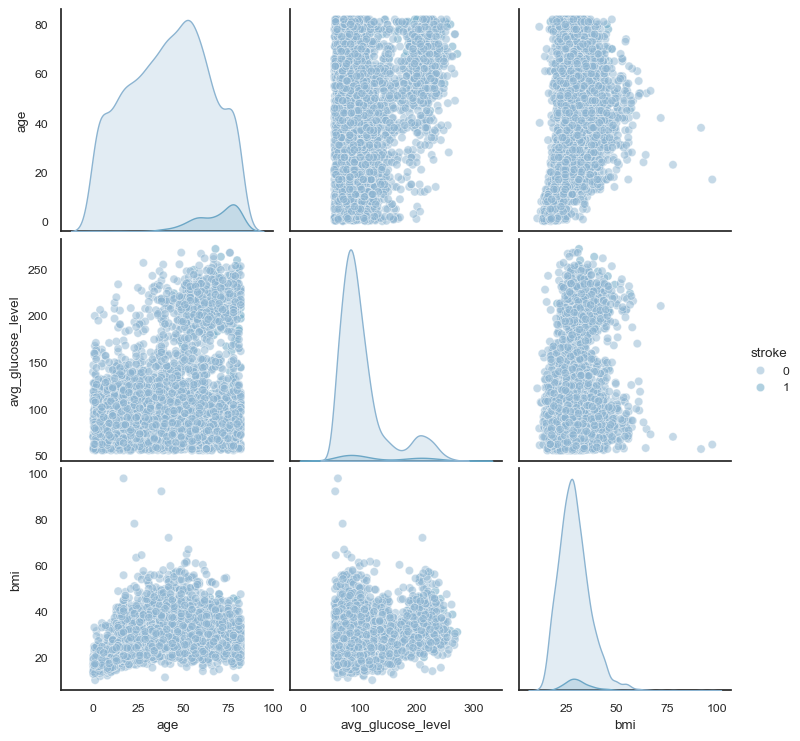

In [16]:
def pairplot_without_stroke(datafreame) -> None:
    subset = datafreame[["age", "avg_glucose_level", 'bmi', 'stroke']]
    subset["stroke"] = subset["stroke"].astype('category')
    sns.pairplot(subset, hue="stroke", plot_kws={"alpha": 0.5})
    plt.show(0)


pairplot_without_stroke(df)

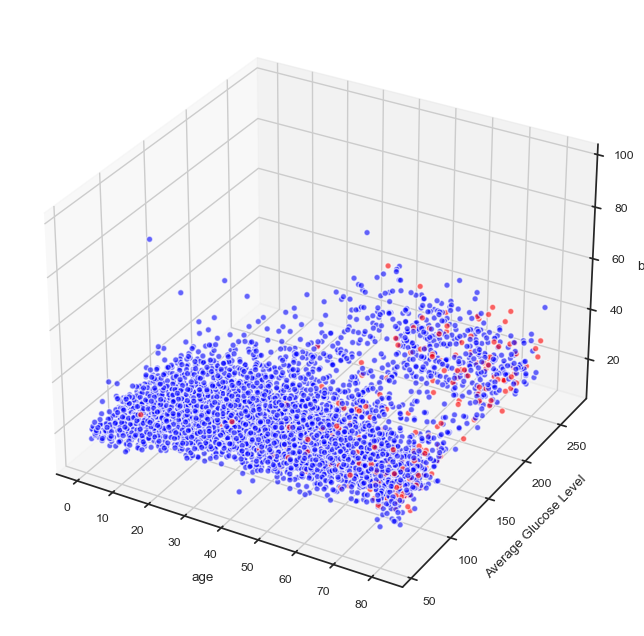

In [19]:
def scatter_three_d(dataframe) -> None:
    colors = dataframe["stroke"].map({0:"blue", 1:"red"})
    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(dataframe["age"], dataframe['avg_glucose_level'], dataframe['bmi'], c=colors, alpha=0.6, edgecolors="w")

    ax.set_xlabel("age")
    ax.set_ylabel("Average Glucose Level")
    ax.set_zlabel("bmi")
    plt.show()


scatter_three_d(df)